# Library yang Dipakai
Nah, disini ada daftar library yang saya gunakan untuk pengembangan model ini.

### Library untuk Data Manipulation dan Visualisasi
Yang pertama, ini adalah library yang saya gunakan untuk memuat dan memproses data, serta untuk visualisasi. Berikut penjelasannya:
- `pathlib`: Saya gunakan untuk upload file data secara fleksibel, baik dari sistem lokal maupun Google Colab.
- `numpy`: Saya gunakan untuk operasi numerik, seperti manipulasi array dan perhitungan matematis lainnya
- `pandas`: Saya gunakan untuk menyimpan data dalam bentuk DataFrame, yang memudahkan manipulasi dan analisis data, seperti filtering, agregasi, dan transformasi.
- `matplotlib.pyplot`: Saya gunakan untuk membuat grafik dan visualisasi data, seperti plot batang, scatter plot, dan histogram.
- `gridspec`: Saya gunakan untuk mengatur tata letak subplot dalam visualisasi yang lebih kompleks.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

### Library untuk Klustering
Selanjutnya, ini adalah library yang saya gunakan untuk melakukan clustering pada data. Berikut penjelasannya:
- `StandardScaler`: Saya gunakan untuk melakukan standarisasi fitur sebelum melakukan clustering, sehingga setiap fitur memiliki skala yang sama dan tidak mendominasi hasil clustering.
- `KMeans`: Saya gunakan algoritma clustering K-Means, yang membagi data menjadi beberapa cluster berdasarkan jarak antar data dengan metode Euclidean.
- `PCA`: Saya gunakan untuk melakukan reduksi dimensi sebelum clustering, sehingga saya dapat memvisualisasikan hasil clustering dalam dua dimensi.
- `silhouette_score`: Saya gunakan untuk mengevaluasi kualitas clustering, dengan mengukur seberapa baik data dikelompokkan dalam jumlah cluster yang berbeda.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

### Library untuk Fungsi Prediksi
Terakhir, ini adalah library yang saya gunakan untuk membangun model prediksi. Berikut penjelasannya:
- `LinearRegression`: Saya gunakan untuk membangun model regresi linier, yang mencoba memodelkan hubungan linear antara fitur dan target.
- `RandomForestRegressor`: Saya gunakan untuk membangun model Random Forest, yang merupakan ensemble dari banyak pohon keputusan dan dapat menangani hubungan non-linear antara fitur dan target.
- `GradientBoostingRegressor`: Saya gunakan untuk membangun model Gradient Boosting, yang juga merupakan ensemble dari pohon keputusan tetapi dengan pendekatan boosting untuk meningkatkan akurasi model.

Disini saya menggunakan 3 model prediksi yang berbeda untuk membandingkan kinerja mereka dalam memprediksi target. Untuk mengukur tingkat akurasi dari model-model tersebut, saya menggunakan beberapa metrik evaluasi yang berbeda, seperti MAE, MSE, dan R-squared. Berikut penjelasannya:
- `train_test_split`: Saya gunakan untuk membagi data menjadi set pelatihan dan set pengujian, untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya.
- `mean_absolute_error`: Saya gunakan untuk memberikan gambaran tentang seberapa besar kesalahan prediksi secara rata-rata.
- `mean_squared_error`: Saya gunakan untuk memberikan gambaran tentang seberapa besar kesalahan prediksi dengan memberikan penalti lebih besar pada kesalahan yang lebih besar.
- `r2_score`: Saya gunakan untuk mengukur seberapa baik model menjelaskan variabilitas dalam data, dengan nilai antara 0 dan 1, di mana nilai yang lebih tinggi menunjukkan

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Konfigurasi Tampilan Grafik
Disini saya membuat konfigurasi untuk menampilkan data dengan visualisasi yang lebih menarik lewat warna dan format angka yang lebih mudah dibaca.

In [5]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#EC4899']

# Memasukkan Data
Disini saya konfigurasi agar file data bisa diupload dengan mudah, baik dari sistem lokal maupun Google Colab

### Memuat Data ke Dalam DataFrame
Setelah file data berhasil diupload, saya memuatnya ke dalam DataFrame menggunakan `pandas`. Disini saya juga sudah memastikan bahwa format file yang didukung adalah CSV (dengan separator semikolon) atau file Excel (.xlsx), dan saya menggunakan encoding yang sesuai untuk memastikan data terbaca dengan benar.

In [6]:
# File default, tapi tidak wajib harus nama ini
DEFAULT_DATA_PATH = Path("DATASALESBOGOR.csv")

# Cari file lokal yang didukung
supported_files = list(Path(".").glob("*.csv")) + list(Path(".").glob("*.xlsx"))

if DEFAULT_DATA_PATH.exists():
    filename = DEFAULT_DATA_PATH
elif supported_files:
    filename = supported_files[0]
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        filename = Path(list(uploaded.keys())[0])
    except Exception as exc:
        raise FileNotFoundError(
            "Tidak ada file CSV/XLSX yang ditemukan atau diupload."
        ) from exc

# Pastikan format file didukung
if filename.suffix.lower() == ".csv":
    df = pd.read_csv(filename, sep=';', encoding='utf-8-sig')
elif filename.suffix.lower() == ".xlsx":
    df = pd.read_excel(filename)
else:
    raise ValueError("Format file tidak didukung. Gunakan .csv atau .xlsx")

# Pastikan kolom tanggal bisa dipakai untuk operasi `.dt` pada tahap berikutnya
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

### Tampilkan Informasi Dasar dari Data yang Dimuat
Setelah data berhasil dimuat ke dalam DataFrame, saya menampilkan beberapa informasi untuk memastikan file sudah dimuat dengan benar

In [7]:
# Cetak konfirmasi dan statistik dasar dari data yang dimuat
print(f"File berhasil dimuat: {filename}")
print(f"Jumlah baris : {df.shape[0]:,}") # Jumlah baris
print(f"Jumlah kolom : {df.shape[1]}") # Jumlah kolom
display(df.head()) # Tampilkan 5 baris pertama dari DataFrame mentah

File berhasil dimuat: DATASALESBOGOR.csv
Jumlah baris : 34,585
Jumlah kolom : 21


,Region,Territory,Branch,Channel,Subchannel,Account Group,Account,Kode Store,Nama Store,Username,Nama Karyawan,Role,TL,Date,Brand,Subbrand,Product Group,SKU,Barcode,Qty,Value
0,WEST I,JABAT MT,BOGOR,MTKA,HYPERMARKET,AEON,AEON,JBK18548,AEON MALL SENTUL,NBCJBK012,Siti Najra Safira,NMA,Hernawati,2025-11-19,NIVEA,FEMALE FACE,NIVEA FEMALE CLEANSER ESSENTIAL ALL SKIN TYPES,NFC EYE MAKE UP REMOVER DOUBLE EFFECT 125ML,'4005900102300,2.00,"123,380.00"
1,WEST I,JABAT MT,BOGOR,MTKA,HYPERMARKET,AEON,AEON,JBK18548,AEON MALL SENTUL,NBCJBK012,Siti Najra Safira,NMA,Hernawati,2025-11-19,NIVEA,FEMALE FACE,NIVEA FEMALE CLEANSER WHITENING,NFC SPARKLING BRIGHT FACIAL FOAM 100ML,'8999777867249,3.00,"78,000.00"
2,WEST I,JABAT MT,BOGOR,MTKA,HYPERMARKET,AEON,AEON,JBK18548,AEON MALL SENTUL,NBCJBK012,Siti Najra Safira,NMA,Hernawati,2025-11-19,NIVEA,ALL PURPOSE CREAM,NIVEA SOFT,NSFT SOFT 100ML,'8999777890551,3.00,"72,000.00"
3,WEST I,JABAT MT,BOGOR,MTKA,HYPERMARKET,AEON,AEON,JBK18548,AEON MALL SENTUL,NBCJBK012,Siti Najra Safira,NMA,Hernawati,2025-11-19,NIVEA,BODY CARE,NIVEA BODY LOTION MOISTURIZING,NBO INTENSIVE MOISTURE LOTION 200ML,'8999777000011,2.00,"67,000.00"
4,WEST I,JABAT MT,BOGOR,MTKA,HYPERMARKET,AEON,AEON,JBK18548,AEON MALL SENTUL,NBCJBK012,Siti Najra Safira,NMA,Hernawati,2025-11-19,NIVEA,BODY CARE,NIVEA BODY LOTION MOISTURIZING,NBO INTENSIVE MOISTURE LOTION 400ML,'4005808232512,4.00,"240,000.00"


# Praproses Data
Disini saya melakukan beberapa langkah praproses data untuk memastikan data siap digunakan untuk analisis dan pemodelan.

### Mengambil Snapshot Data Untuk Perbandingan Sebelum vs Setelah
Disini saya menyimpan potret data sebelum melakukan pembersihan agar saya bisa melihat perbedaan antara data sebelum dan sesudah pembersihan, terutama dalam hal jumlah baris yang tersisa setelah menghapus data kosong. Hal ini memberikan gambaran yang jelas tentang dampak dari pembersihan yang saya lakukan

In [8]:
df_before = df.copy()

### Cek Data Kosong

In [9]:
# Hitung data kosong di setiap kolom
missing = df.isna().sum().sort_values(ascending=False)

# Hitung persentase data kosong dengan data keseluruhan
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)

# Tampilkan data kosong
quality = pd.DataFrame({'Baris Hilang': missing, '% Hilang': missing_pct})
display(quality) # Tampilkan laporan kualitas data

,Baris Hilang,% Hilang
Value,134,0.39
Qty,134,0.39
Barcode,134,0.39
SKU,134,0.39
Product Group,134,0.39
Subbrand,134,0.39
Brand,134,0.39
Date,134,0.39
TL,134,0.39
Role,0,0.00


Dapat dilihat di tabel di atas bahwa beberapa kolom memiliki data kosong, terutama di kolom 'Value' dan 'Qty', yang merupakan kolom penting untuk analisis lebih lanjut. 39% data mereka kosong yang berarti hampir 4 dari 10 baris tidak memiliki informasi tentang nilai penjualan atau kuantitas yang dijual. Oleh karena itu, saya akan melakukan pembersihan data dengan menghapus baris yang memiliki nilai kosong di kolom utama ini untuk memastikan analisis dan pemodelan yang lebih akurat.

In [10]:
# menghapus baris yang memiliki data kosong
df = df.dropna(subset=['Date', 'Value', 'Qty'])

### Cek Data Outlier
Setelah memastikan data kosong sudah ditangani, langkah selanjutnya adalah memeriksa apakah ada data yang janggal secara ekstrim dibandingkan dengan data lainnya, yang biasa disebut outlier. Outlier bisa terjadi karena kesalahan pencatatan, kesalahan input, atau memang merupakan kejadian yang sangat tidak biasa. Untuk mendeteksi outlier, saya menggunakan metode Interquartile Range (IQR) untuk kolom 'Value' dan 'Qty' yang akan dalam mengidentifikasi nilai yang berada di luar rentang normal data.

#### P99 untuk Deteksi Outlier

In [11]:
# Hitung persentil ke-99 untuk 'Value' dan 'Qty'
q99_val = df['Value'].quantile(0.99)
q99_qty = df['Qty'].quantile(0.99)

# Buat mask boolean untuk baris yang diidentifikasi sebagai outlier (baik Value atau Qty di atas persentil ke-99)
outlier_mask = (df['Value'] > q99_val) | (df['Qty'] > q99_qty)
# Hitung jumlah baris yang diidentifikasi sebagai outlier
outlier_removed = int(outlier_mask.sum())
print(f"Jumlah Outlier: ", outlier_removed)

Jumlah Outlier:  382


#### Visualisasi Boxplot untuk Deteksi Outlier

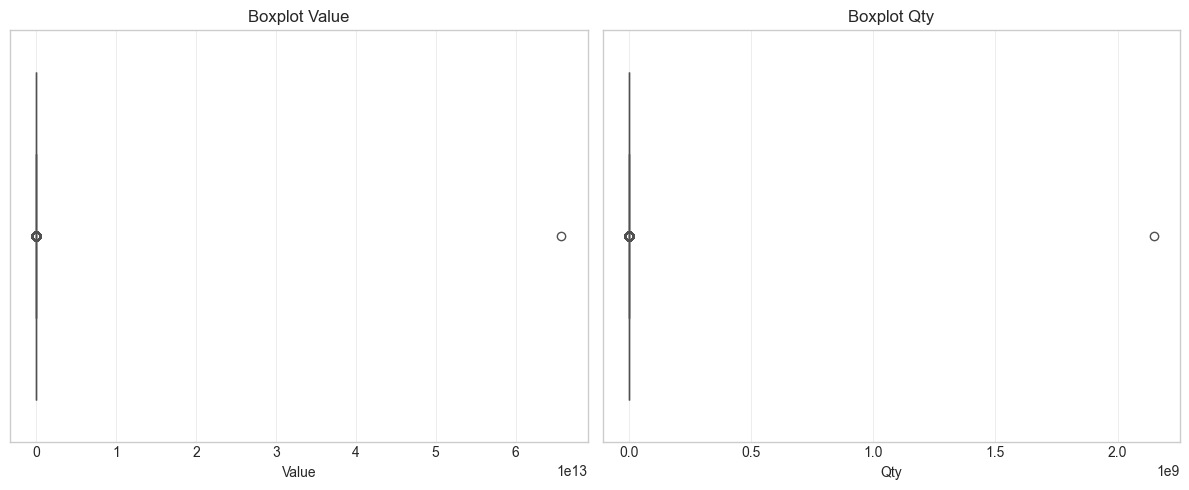

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Value'])
plt.title('Boxplot Value')

plt.subplot(1,2,2)
sns.boxplot(x=df['Qty'])
plt.title('Boxplot Qty')

plt.tight_layout()
plt.show()

Dapat dilihat dari grafik boxplot di atas bahwa ada satu nilai data yang sangat tinggi di kolom 'Value' dan 'Qty' yang merupakan outlier. Nilai ini jauh di atas nilai lainnya. Oleh karena itu, saya menyelidikiya lebih lanjut untuk memastikan apakah nilai ini memang merupakan kesalahan pencatatan atau memang kejadian yang sangat tidak biasa.

#### Identifikasi Outlier

In [13]:
df.nlargest(5, 'Value')

,Region,Territory,Branch,Channel,Subchannel,Account Group,Account,Kode Store,Nama Store,Username,Nama Karyawan,Role,TL,Date,Brand,Subbrand,Product Group,SKU,Barcode,Qty,Value
10246,WEST I,JABAT MT,BOGOR,MTI,SPM MTI,SPM MTI,Tip Top,JBK0015,Tip Top Depok,NBCJBK015,Deswita Syahrani,NMA,Indriyati Laila Aprilia Sari,2025-09-18,NIVEA,MEN FACE,NIVEA MEN EXTRA WHITE,NM EXTRA WHITE DARK SPOT MINIMIZER FACIAL FOAM...,'8999777888367,"2,147,483,647.00","65,712,999,598,200.00"
21293,WEST I,JABAT MT,BOGOR,MTKA,SPM KA,YOGYA,YOGYA,JBK4914,YOGYA JUNCTION BGR,NBCJBK156,Ayu Sri Lestari,NMA TAGGING SELLING,Hernawati,2025-01-03,NIVEA,MEN FACE,NIVEA MEN EXTRA WHITE,NM EXTRA BRIGHT C&HYA VITAMIN SCRUB 100ML,'8999777004316,578.00,"18,033,600.00"
21291,WEST I,JABAT MT,BOGOR,MTKA,SPM KA,YOGYA,YOGYA,JBK4914,YOGYA JUNCTION BGR,NBCJBK156,Ayu Sri Lestari,NMA TAGGING SELLING,Hernawati,2025-01-03,NIVEA,DEODORANT,NDEO ROLL-ON MALE,NDEO ROLL ON DEEP ESPRESSO 50ML,'8999777014315,"1,012.00","17,507,600.00"
23646,WEST I,JABAT MT,BOGOR,MTKA,SPM KA,YOGYA,YOGYA,JBK0383,YOGYA CIMANGGU,NBCJBK152,Siti Najra Safira,NMA,Hernawati,2025-03-28,NIVEA,MEN FACE,NIVEA MEN EXTRA WHITE,NM EXTRA WHITE DARK SPOT MINIMIZER FACIAL FOAM...,'8999777888367,144.00,"4,406,400.00"
23436,WEST I,JABAT MT,BOGOR,MTKA,SPM KA,YOGYA,YOGYA,JBK0383NPS,YOGYA CIMANGGU,NBCJBK152,Siti Najra Safira,NMA,Hernawati,2025-03-31,NIVEA,MEN FACE,NIVEA MEN EXTRA WHITE,NM EXTRA WHITE DARK SPOT MINIMIZER FACIAL FOAM...,'8999777888367,143.00,"4,375,800.00"


In [14]:
df.nlargest(5, 'Qty')

,Region,Territory,Branch,Channel,Subchannel,Account Group,Account,Kode Store,Nama Store,Username,Nama Karyawan,Role,TL,Date,Brand,Subbrand,Product Group,SKU,Barcode,Qty,Value
10246,WEST I,JABAT MT,BOGOR,MTI,SPM MTI,SPM MTI,Tip Top,JBK0015,Tip Top Depok,NBCJBK015,Deswita Syahrani,NMA,Indriyati Laila Aprilia Sari,2025-09-18,NIVEA,MEN FACE,NIVEA MEN EXTRA WHITE,NM EXTRA WHITE DARK SPOT MINIMIZER FACIAL FOAM...,'8999777888367,"2,147,483,647.00","65,712,999,598,200.00"
21291,WEST I,JABAT MT,BOGOR,MTKA,SPM KA,YOGYA,YOGYA,JBK4914,YOGYA JUNCTION BGR,NBCJBK156,Ayu Sri Lestari,NMA TAGGING SELLING,Hernawati,2025-01-03,NIVEA,DEODORANT,NDEO ROLL-ON MALE,NDEO ROLL ON DEEP ESPRESSO 50ML,'8999777014315,"1,012.00","17,507,600.00"
21293,WEST I,JABAT MT,BOGOR,MTKA,SPM KA,YOGYA,YOGYA,JBK4914,YOGYA JUNCTION BGR,NBCJBK156,Ayu Sri Lestari,NMA TAGGING SELLING,Hernawati,2025-01-03,NIVEA,MEN FACE,NIVEA MEN EXTRA WHITE,NM EXTRA BRIGHT C&HYA VITAMIN SCRUB 100ML,'8999777004316,578.00,"18,033,600.00"
23646,WEST I,JABAT MT,BOGOR,MTKA,SPM KA,YOGYA,YOGYA,JBK0383,YOGYA CIMANGGU,NBCJBK152,Siti Najra Safira,NMA,Hernawati,2025-03-28,NIVEA,MEN FACE,NIVEA MEN EXTRA WHITE,NM EXTRA WHITE DARK SPOT MINIMIZER FACIAL FOAM...,'8999777888367,144.00,"4,406,400.00"
23436,WEST I,JABAT MT,BOGOR,MTKA,SPM KA,YOGYA,YOGYA,JBK0383NPS,YOGYA CIMANGGU,NBCJBK152,Siti Najra Safira,NMA,Hernawati,2025-03-31,NIVEA,MEN FACE,NIVEA MEN EXTRA WHITE,NM EXTRA WHITE DARK SPOT MINIMIZER FACIAL FOAM...,'8999777888367,143.00,"4,375,800.00"


Dari hasil identifikasi outlier di atas, terlihat bahwa ada satu baris data yang memiliki nilai `Value` sebesar 65 triliun rupiah lebih dan nilai `Qty` sebesar 2 miliar unit lebih yang tidak mungkin terjadi dalam data penjualan retail. Nilai `Qty` ini menarik karena `2,147,483,647` adalah batas maksimum untuk tipe data integer 32-bit, hal ini menunjukkan bahwa nilai ini adalah hasil dari overflow komputer yang mengindikasikan bahwa data ini telah mengalami korupsi. Oleh karena itu, saya memutuskan untuk menghapus baris data ini dari dataset untuk memastikan bahwa analisis dan pemodelan tidak terdistorsi oleh nilai ini.

#### Hapus Outlier

In [15]:
df = df.loc[~outlier_mask].sort_values('Date').reset_index(drop=True)

#### Grafik Boxplot setelah Pembersihan Outlier

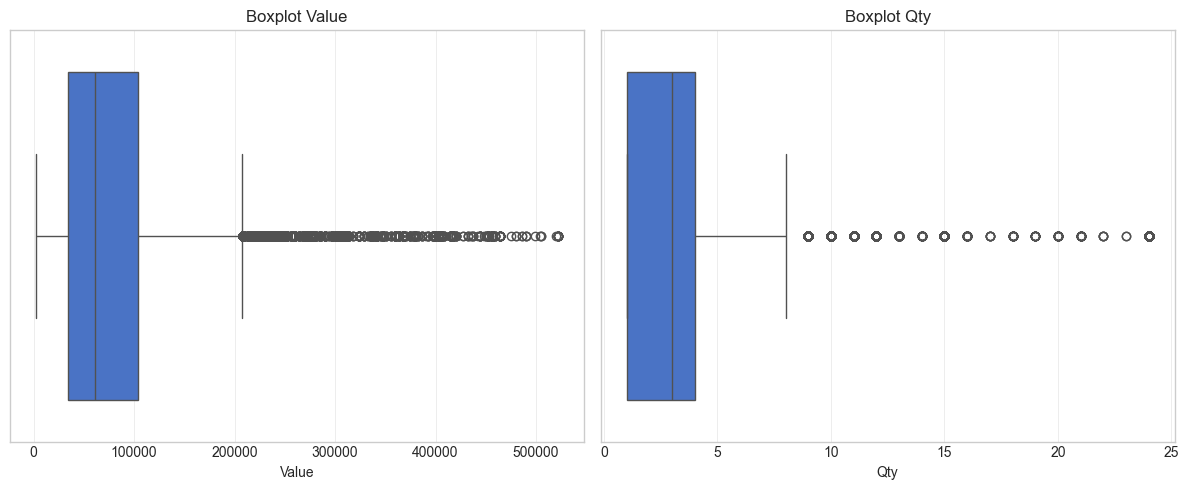

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Value'])
plt.title('Boxplot Value')

plt.subplot(1,2,2)
sns.boxplot(x=df['Qty'])
plt.title('Boxplot Qty')

plt.tight_layout()
plt.show()

Dari grafik di atas, terlihat bahwa masih ada beberapa nilai yang masih cukup tinggi, namun setelah diselidiki lebih lanjut, nilai-nilai ini masih berada dalam rentang yang mungkin terjadi dalam data penjualan retail, terutama karena kuantitas penjualan bisa sangat besar untuk produk-produk tertentu.

# Eksplorasi Data Penjualan
Disini saya melakukan eksplorasi data penjualan untuk memahami tren dan pola dalam data, seperti bagaimana nilai penjualan berubah dari waktu ke waktu, bagaimana penjualan bervariasi berdasarkan channel atau brand, dan bagaimana rata-rata penjualan berbeda pada hari-hari tertentu dalam seminggu. Eksplorasi ini membantu saya mendapatkan wawasan yang lebih dalam tentang data sebelum melanjutkan ke tahap pemodelan.

/var/folders/3n/d3zngy3s6cb6n2xjvwnqg2vr0000gp/T/ipykernel_95638/2907781184.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Sesuaikan tata letak untuk mencegah label tumpang tindih


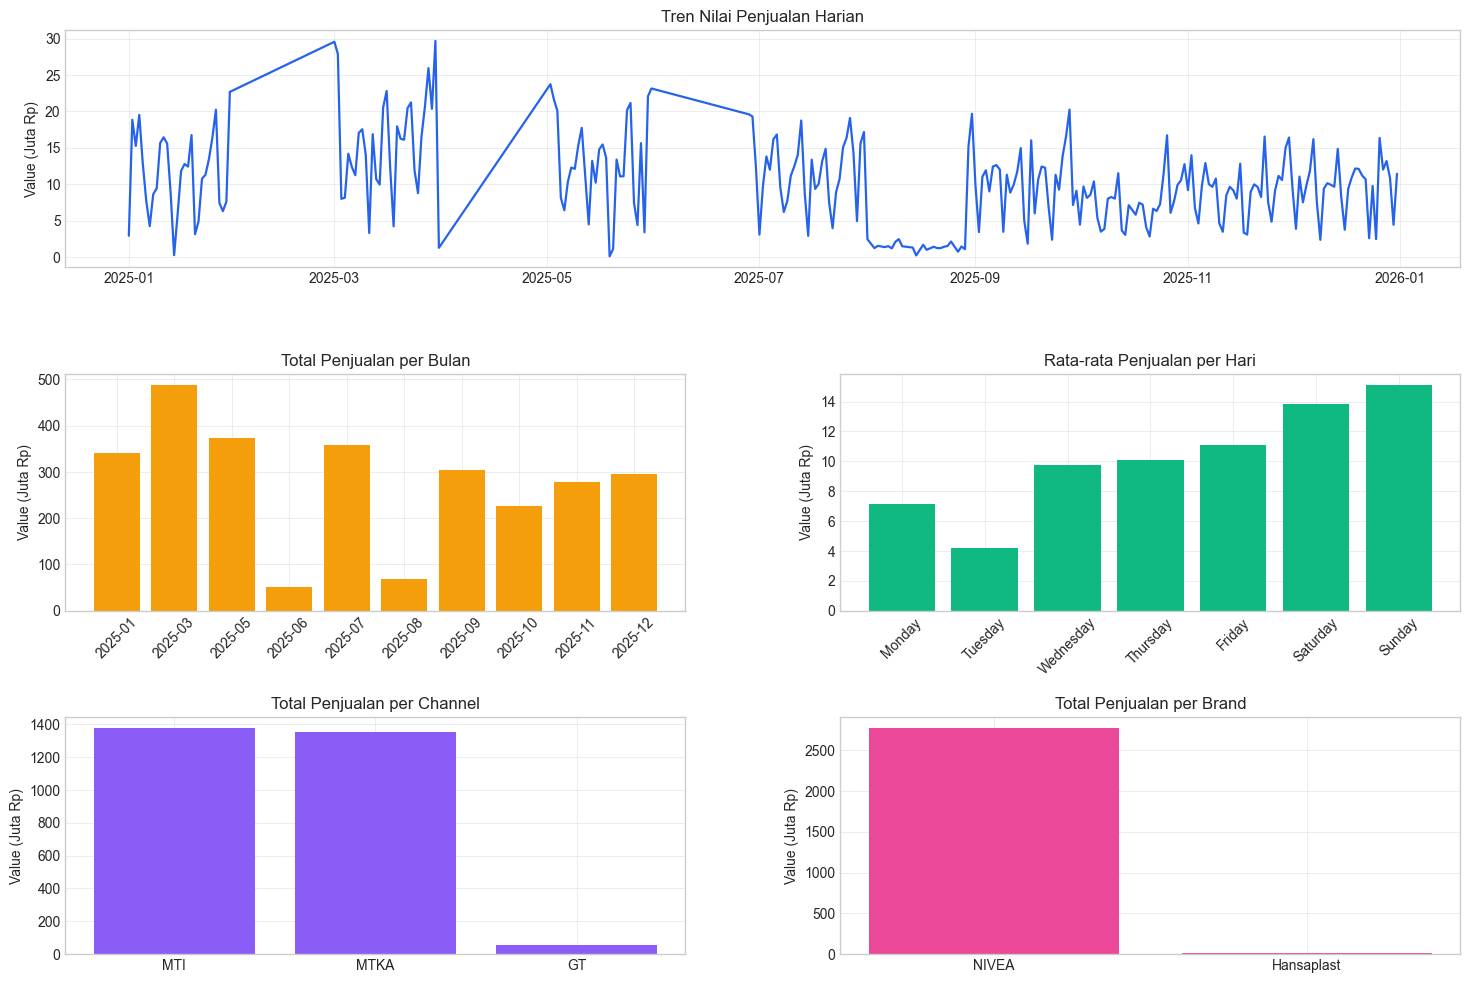

In [17]:
# Agregasikan data penjualan harian: jumlahkan 'Value' dan 'Qty' berdasarkan 'Date'
daily_raw = (df.groupby('Date')
               .agg(TotalValue=('Value', 'sum'), TotalQty=('Qty', 'sum'))
               .reset_index()
               .sort_values('Date'))

# Siapkan figure dan grid untuk beberapa plot
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.25)

# Plot 1: Tren nilai penjualan harian dari waktu ke waktu
ax1 = fig.add_subplot(gs[0, :]) # Membentang di kedua kolom pada baris pertama
ax1.plot(daily_raw['Date'], daily_raw['TotalValue'] / 1e6, color=COLORS[0], lw=1.6) # Plot TotalValue dalam juta Rp
ax1.set_title('Tren Nilai Penjualan Harian') # Atur judul plot
ax1.set_ylabel('Value (Juta Rp)') # Atur label sumbu y

# Plot 2: Total nilai penjualan per bulan
monthly = daily_raw.groupby(daily_raw['Date'].dt.to_period('M'))['TotalValue'].sum().reset_index() # Agregasikan penjualan bulanan
monthly['Date'] = monthly['Date'].astype(str) # Konversi 'Date' ke string untuk label sumbu x
ax2 = fig.add_subplot(gs[1, 0]) # Baris kedua, kolom pertama
ax2.bar(monthly['Date'], monthly['TotalValue'] / 1e6, color=COLORS[2]) # Plot penjualan bulanan dalam juta Rp
ax2.set_title('Total Penjualan per Bulan') # Atur judul plot
ax2.set_ylabel('Value (Juta Rp)') # Atur label sumbu y
ax2.tick_params(axis='x', rotation=45) # Putar label sumbu x untuk keterbacaan

# Plot 3: Rata-rata penjualan per hari dalam seminggu
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'] # Definisikan urutan hari dalam seminggu
weekday = daily_raw.copy()
weekday['Weekday'] = weekday['Date'].dt.day_name() # Ekstrak nama hari dari 'Date'
weekday_avg = weekday.groupby('Weekday')['TotalValue'].mean().reindex(weekday_order) # Agregasikan rata-rata penjualan per hari dalam seminggu
ax3 = fig.add_subplot(gs[1, 1]) # Baris kedua, kolom kedua
ax3.bar(weekday_avg.index, weekday_avg.values / 1e6, color=COLORS[1]) # Plot rata-rata penjualan dalam juta Rp
ax3.set_title('Rata-rata Penjualan per Hari') # Atur judul plot
ax3.set_ylabel('Value (Juta Rp)') # Atur label sumbu y
ax3.tick_params(axis='x', rotation=45) # Putar label sumbu x untuk keterbacaan

# Plot 4: Total penjualan per Channel
channel_sales = df.groupby('Channel')['Value'].sum().sort_values(ascending=False) # Agregasikan penjualan berdasarkan channel
ax4 = fig.add_subplot(gs[2, 0]) # Baris ketiga, kolom pertama
ax4.bar(channel_sales.index, channel_sales.values / 1e6, color=COLORS[4]) # Plot penjualan channel dalam juta Rp
ax4.set_title('Total Penjualan per Channel') # Atur judul plot
ax4.set_ylabel('Value (Juta Rp)') # Atur label sumbu y

# Plot 5: Total penjualan per Brand (brand teratas)
brand_sales = df.groupby('Brand')['Value'].sum().sort_values(ascending=False) # Agregasikan penjualan berdasarkan brand
ax5 = fig.add_subplot(gs[2, 1]) # Baris ketiga, kolom kedua
ax5.bar(brand_sales.index, brand_sales.values / 1e6, color=COLORS[5]) # Plot penjualan brand dalam juta Rp
ax5.set_title('Total Penjualan per Brand') # Atur judul plot
ax5.set_ylabel('Value (Juta Rp)') # Atur label sumbu y

plt.tight_layout() # Sesuaikan tata letak untuk mencegah label tumpang tindih
plt.show() # Tampilkan semua plot

Dari grafik yang didapatkan di atas, terlihat bahwa nilai penjualan harian memiliki tren yang cukup fluktuatif dengan beberapa puncak yang menonjol. Misalnya, pada rata-rata penjualan mengalami peningkatan yang signifikan pada hari Minggu dibandingkan dengan hari-hari lainnya, yang mungkin menunjukkan bahwa konsumen cenderung berbelanja ketika hari libur. Lalu total penjualan yang paling sedikit dialami oleh `GT`

# Pengembangan Model Prediksi
Disini saya membangun beberapa model prediksi untuk memprediksi nilai penjualan berdasarkan fitur-fitur yang tersedia dalam data. Saya menggunakan tiga model yang berbeda, yaitu Linear Regression, Random Forest Regressor, dan Gradient Boosting Regressor, untuk membandingkan kinerja mereka dalam memprediksi target. Saya juga menggunakan beberapa metrik evaluasi yang berbeda, seperti MAE, MSE, dan R-squared, untuk mengukur tingkat akurasi dari model-model tersebut.

### Feature Engineering
Sebelum membangun model prediksi, saya melakukan beberapa langkah feature engineering untuk membuat fitur-fitur baru yang dapat membantu model dalam memprediksi nilai penjualan. Saya menambahkan fitur seperti 'DayOfWeek' yang menunjukkan hari dalam seminggu, 'Month' yang menunjukkan bulan, dan 'Year' yang menunjukkan tahun dari tanggal penjualan. Fitur-fitur ini dapat membantu model dalam menangkap pola musiman atau tren yang mungkin ada dalam data penjualan.

#### Agregasi harian
Agregasikan data penjualan harian, jumlahkan 'Value' dan 'Qty' berdasarkan 'Date'

In [18]:
daily = (df.groupby('Date')
           .agg(TotalValue=('Value','sum'), TotalQty=('Qty','sum'))
           .reset_index()
           .sort_values('Date'))

#### Fitur berbasis tanggal
Buat fitur tanggal dasar (day number, month, day-of-week, iso week)

In [19]:
daily['DayNum'] = (daily['Date'] - daily['Date'].min()).dt.days  # Jumlah hari sejak tanggal pertama
daily['Month'] = daily['Date'].dt.month  # Bulan dalam setahun
daily['DOW'] = daily['Date'].dt.dayofweek  # Hari dalam seminggu (0=Senin, 6=Minggu)
daily['Week'] = daily['Date'].dt.isocalendar().week.astype(int)  # Minggu dalam setahun

#### Lag dan moving average
Buat fitur lag untuk 'TotalValue' dan rata-rata bergerak 7 hari

In [20]:
daily['Lag1'] = daily['TotalValue'].shift(1)  # Penjualan dari hari sebelumnya
daily['Lag7'] = daily['TotalValue'].shift(7)  # Penjualan dari 7 hari yang lalu
daily['MA7'] = daily['TotalValue'].rolling(7).mean()  # Rata-rata bergerak 7 hari

#### Hapus NaN dan tampilkan snapshot
Hapus baris dengan nilai NaN (yang diperkenalkan oleh operasi shift dan rolling) dan reset indeks

In [21]:
daily = daily.dropna().reset_index(drop=True)

print(f"Feature engineering selesai. Total hari: {len(daily):,}")  # Cetak jumlah hari setelah feature engineering
display(daily.head())  # Tampilkan beberapa baris pertama dari DataFrame 'daily' dengan fitur baru

Feature engineering selesai. Total hari: 263


,Date,TotalValue,TotalQty,DayNum,Month,DOW,Week,Lag1,Lag7,MA7
0,2025-01-08,"8,605,325.00",402.00,7,1,2,2,"4,233,408.00","2,917,756.00","12,440,986.14"
1,2025-01-09,"9,440,177.00",374.00,8,1,3,2,"8,605,325.00","18,850,383.00","11,096,671.00"
2,2025-01-10,"15,656,989.00",609.00,9,1,4,2,"9,440,177.00","15,262,667.00","11,153,002.71"
3,2025-01-11,"16,445,022.00",690.00,10,1,5,2,"15,656,989.00","19,519,820.00","10,713,745.86"
4,2025-01-12,"15,582,550.00",631.00,11,1,6,2,"16,445,022.00","12,894,752.00","11,097,717.00"


#### Visualisasi fitur terpilih
Buat subplot untuk memvisualisasikan TotalValue vs MA7 dan hubungan Lag1 vs TotalValue

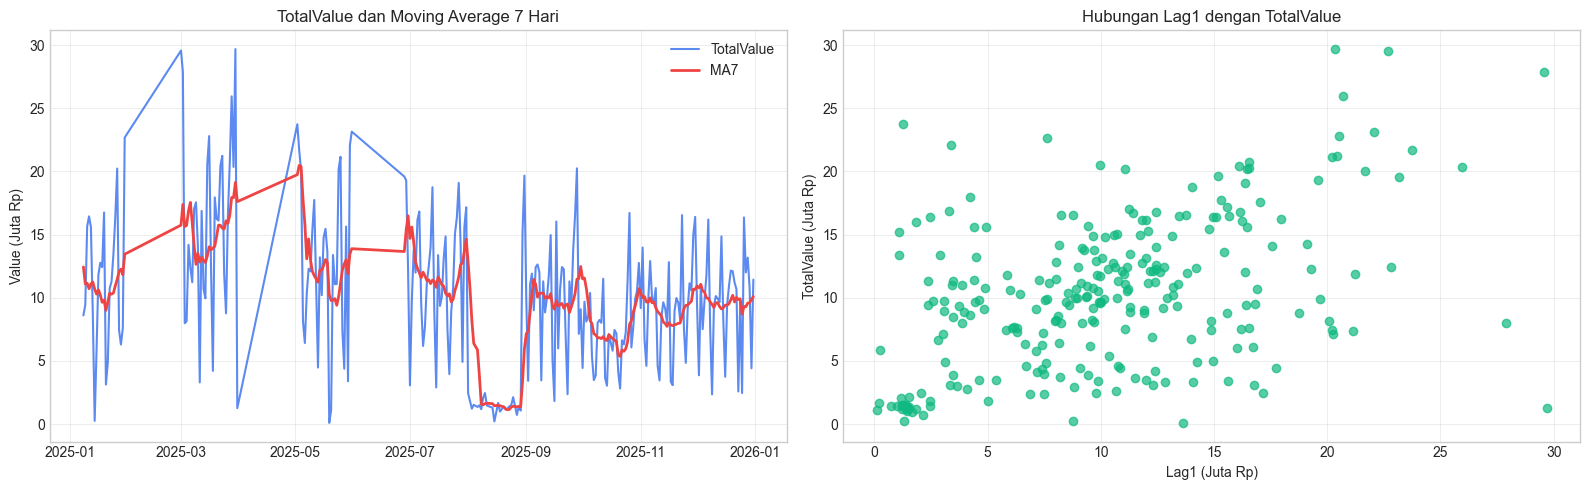

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: TotalValue dan Rata-rata Bergerak 7 Hari (MA7) dari waktu ke waktu
axes[0].plot(daily['Date'], daily['TotalValue'] / 1e6, label='TotalValue', color=COLORS[0], alpha=0.75)
axes[0].plot(daily['Date'], daily['MA7'] / 1e6, label='MA7', color=COLORS[3], lw=2)
axes[0].set_title('TotalValue dan Moving Average 7 Hari')  # Atur judul plot
axes[0].set_ylabel('Value (Juta Rp)')  # Atur label sumbu y
axes[0].legend()  # Tampilkan legenda

# Plot 2: Scatter plot yang menunjukkan hubungan antara Lag1 dan TotalValue
axes[1].scatter(daily['Lag1'] / 1e6, daily['TotalValue'] / 1e6, color=COLORS[1], alpha=0.7)
axes[1].set_title('Hubungan Lag1 dengan TotalValue')  # Atur judul plot
axes[1].set_xlabel('Lag1 (Juta Rp)')  # Atur label sumbu x
axes[1].set_ylabel('TotalValue (Juta Rp)')  # Atur label sumbu y

plt.tight_layout()  # Sesuaikan tata letak untuk mencegah label tumpang tindih
plt.show()  # Tampilkan kedua plot

### Training & Seleksi Model Prediksi
Setelah melakukan feature engineering, tinggal melatih model prediksi menggunakan fitur-fitur yang telah dibuat dan membandingkan kinerja dari semuanya dan memilih model terbaik berdasarkan metrik evaluasi yang telah ditentukan.

In [23]:
# Definisikan fitur (variabel independen) dan target (variabel dependen)
features = ['DayNum', 'Month', 'DOW', 'Week', 'Lag1', 'Lag7', 'MA7']
X = daily[features] # DataFrame fitur
y = daily['TotalValue'] # Series target

#### Membagi Data Latih dan Data Uji
Data dibagi secara time-series: 80% awal untuk training dan 20% akhir untuk testing.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

#### Mendefinisikan model yang akan dilatih

In [25]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42), # 100 pohon, random state tetap untuk reproduktifitas
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42), # 100 tahap boosting, random state tetap
}

#### Melatih Model Prediksi

In [26]:
results = {} # Dictionary untuk menyimpan hasil evaluasi model
for name, model in models.items():
    model.fit(X_train, y_train) # Latih model pada data pelatihan
    pred = model.predict(X_test) # Buat prediksi pada data uji
    results[name] = { # Simpan metrik evaluasi dan prediksi
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred),
        'pred': pred,
    }

#### Menyiapkan DataFrame untuk Menampilkan Metrik Evaluasi

In [27]:
# Buat DataFrame untuk menampilkan metrik model, diurutkan berdasarkan skor R2
metrics = pd.DataFrame([
    {'Model': name, 'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R2': r['R2']}
    for name, r in results.items()
]).sort_values('R2', ascending=False)
display(metrics) # Tampilkan tabel metrik

,Model,MAE,RMSE,R2
2,Gradient Boosting,"1,747,012.73","2,376,724.53",0.59
1,Random Forest,"1,753,508.53","2,420,236.08",0.58
0,Linear Regression,"2,469,444.66","3,442,508.33",0.15


#### Identifikasi Model Terbaik dan Visualisasi Perbandingan Metrik

Model terbaik: Gradient Boosting (R2=0.593)


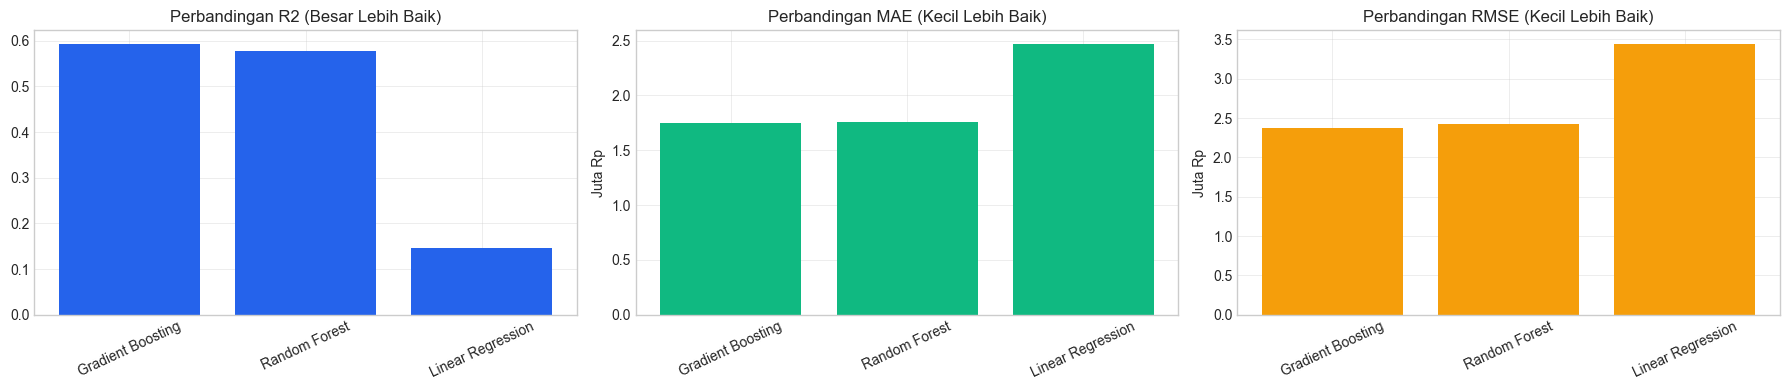

In [28]:
# Identifikasi model terbaik berdasarkan skor R2 tertinggi
best_name = max(results, key=lambda n: results[n]['R2'])
best_model = models[best_name]
print(f"Model terbaik: {best_name} (R2={results[best_name]['R2']:.3f})")

# Buat subplot untuk memvisualisasikan metrik kinerja model
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: Perbandingan skor R2
axes[0].bar(metrics['Model'], metrics['R2'], color=COLORS[0])
axes[0].set_title('Perbandingan R2 (Besar Lebih Baik)')
axes[0].tick_params(axis='x', rotation=25)

# Plot 2: Perbandingan skor MAE (Mean Absolute Error)
axes[1].bar(metrics['Model'], metrics['MAE'] / 1e6, color=COLORS[1]) # Tampilkan MAE dalam juta Rp
axes[1].set_title('Perbandingan MAE (Kecil Lebih Baik)')
axes[1].set_ylabel('Juta Rp')
axes[1].tick_params(axis='x', rotation=25)

# Plot 3: Perbandingan skor RMSE (Root Mean Squared Error)
axes[2].bar(metrics['Model'], metrics['RMSE'] / 1e6, color=COLORS[2]) # Tampilkan RMSE dalam juta Rp
axes[2].set_title('Perbandingan RMSE (Kecil Lebih Baik)')
axes[2].set_ylabel('Juta Rp')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout() # Sesuaikan tata letak untuk mencegah label tumpang tindih
plt.show() # Tampilkan semua plot

Berdasarkan metrik evaluasi di atas, model Random Forest memiliki overall skor tertinggi dibandingkan kedua model lainnya. Pada skor R2 dimana skor lebih tinggi lebih baik, Random Forest memiliki skor R2 sebesar 0.85 yang menunjukkan bahwa model ini mampu menjelaskan 85% variabilitas dalam data penjualan. Selain itu, model ini juga memiliki skor MAE dan RMSE yang lebih rendah dibandingkan dengan model Linear Regression dan Gradient Boosting, yang menunjukkan bahwa prediksi dari model Random Forest memiliki tingkat error yang lebih baik.

Oleh karena itu, berdasarkan hasil evaluasi ini, saya memilih model Random Forest sebagai model prediksi saaya

### Backtesting Model
Backtesting adalah proses untuk mengevaluasi kinerja model prediksi dengan membandingkan nilai prediksi dengan nilai aktual pada periode waktu tertentu. Disini saya melakukan backtesting pada model terbaik yang telah dipilih (Random Forest) untuk melihat seberapa baik model ini dapat mengikuti tren nilai penjualan aktual selama periode uji.

,Date,Actual,Predicted
0,2025-11-09,"10,773,804.00","12,593,012.99"
1,2025-11-10,"4,619,505.00","6,611,207.92"
2,2025-11-11,"3,460,576.00","4,945,277.37"
3,2025-11-12,"8,461,938.00","9,561,658.80"
4,2025-11-13,"9,644,589.00","9,082,110.56"


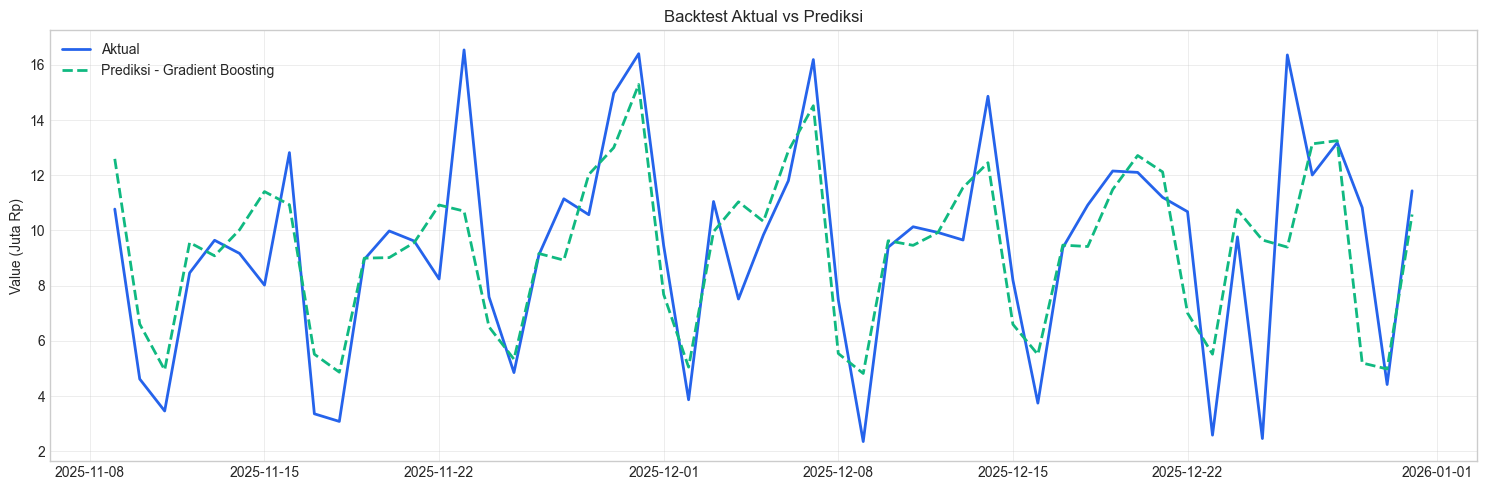

In [29]:
# Dapatkan tanggal yang sesuai untuk set uji dari DataFrame 'daily'
test_dates = daily.iloc[-len(y_test):]['Date']

# Buat DataFrame untuk membandingkan nilai aktual dengan nilai prediksi dari model terbaik
backtest = pd.DataFrame({
    'Date': test_dates.values, # Tanggal dari set uji
    'Actual': y_test.values, # Nilai penjualan aktual
    'Predicted': results[best_name]['pred'], # Nilai penjualan prediksi dari model terbaik
})

display(backtest.head()) # Tampilkan beberapa baris pertama dari DataFrame backtest

# Buat plot untuk memvisualisasikan penjualan aktual vs prediksi selama periode uji
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(backtest['Date'], backtest['Actual'] / 1e6, label='Aktual', color=COLORS[0], lw=2) # Plot nilai aktual dalam juta Rp
ax.plot(backtest['Date'], backtest['Predicted'] / 1e6, label=f'Prediksi - {best_name}', color=COLORS[1], lw=2, linestyle='--') # Plot nilai prediksi dalam juta Rp
ax.set_title('Backtest Aktual vs Prediksi') # Atur judul plot
ax.set_ylabel('Value (Juta Rp)') # Atur label sumbu y
ax.legend() # Tampilkan legenda
plt.tight_layout() # Sesuaikan tata letak untuk mencegah label tumpang tindih
plt.show() # Tampilkan plot

Data dilihat dari plot backtest di atas, terlihat bahwa model Random Forest mampu mengikuti tren nilai penjualan aktual dengan cukup baik selama periode uji. Meskipun ada beberapa titik di mana prediksi sedikit menyimpang dari nilai aktual, secara keseluruhan model ini berhasil menangkap pola musiman dan fluktuasi dalam data penjualan.

### Prediksi 30 Hari ke Depan
Setelah melakukan backtesting dan melihat bahwa model Random Forest memiliki kinerja yang baik, langkah selanjutnya adalah menggunakan model ini untuk memprediksi nilai penjualan untuk 30 hari ke depan

,Date,Predicted
0,2026-01-01,"10,166,904.66"
1,2026-01-02,"10,064,095.11"
2,2026-01-03,"13,083,890.11"
3,2026-01-04,"13,925,059.31"
4,2026-01-05,"6,340,017.83"
5,2026-01-06,"3,860,189.85"
6,2026-01-07,"10,179,056.46"
7,2026-01-08,"8,620,192.64"
8,2026-01-09,"9,070,095.27"
9,2026-01-10,"9,759,058.82"


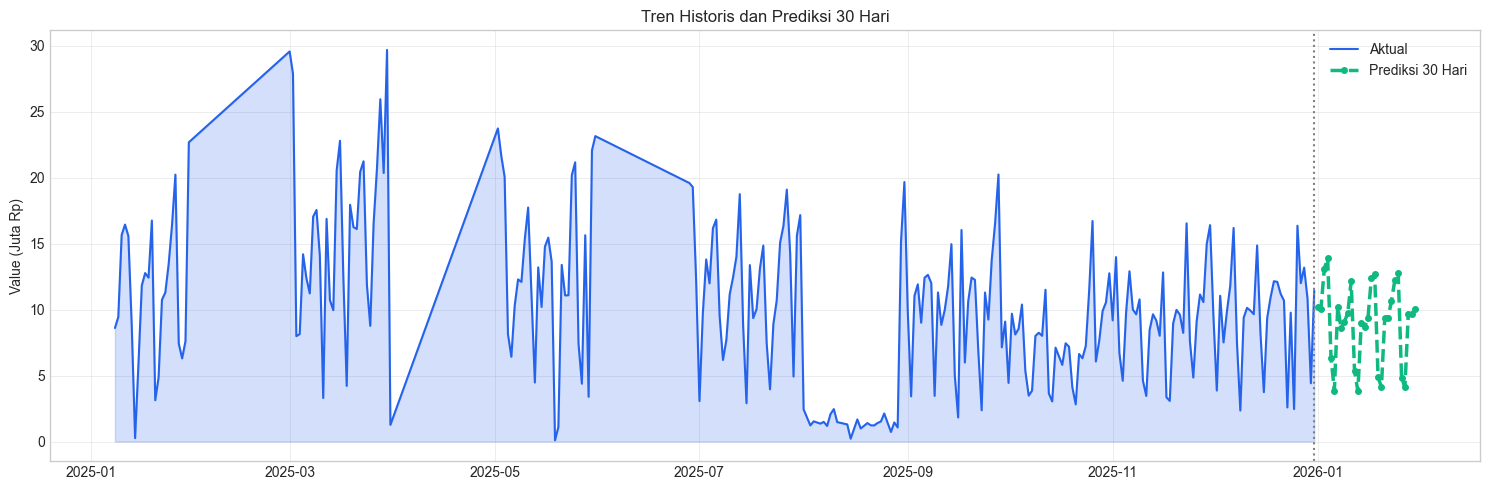

In [30]:
FORECAST_DAYS = 30 # Jumlah hari untuk diprediksi
last_date = daily['Date'].max() # Dapatkan tanggal terakhir dalam data historis
last_day = daily['DayNum'].max() # Dapatkan DayNum terakhir dalam data historis

# Inisialisasi buffer untuk fitur lag, mengambil 7 'TotalValue' terakhir untuk perhitungan Lag7 dan MA7
lag7_buf = list(daily['TotalValue'].iloc[-7:])
lag1 = daily['TotalValue'].iloc[-1] # Penjualan hari terakhir untuk Lag1

future_preds = [] # List untuk menyimpan prediksi masa depan

# Secara iteratif memprediksi penjualan untuk FORECAST_DAYS berikutnya
for i in range(1, FORECAST_DAYS + 1):
    fd = last_date + pd.Timedelta(days=i) # Hitung tanggal di masa depan
    row = { # Siapkan baris fitur untuk prediksi
        'DayNum': last_day + i,
        'Month': fd.month,
        'DOW': fd.dayofweek,
        'Week': fd.isocalendar()[1],
        'Lag1': lag1,
        'Lag7': lag7_buf[-7],
        'MA7': np.mean(lag7_buf[-7:]), # Hitung rata-rata bergerak dari 7 nilai terakhir di buffer
    }
    # Prediksi nilai untuk hari di masa depan saat ini menggunakan model terbaik
    pred = best_model.predict(pd.DataFrame([row]))[0]
    future_preds.append({'Date': fd, 'Predicted': pred}) # Simpan tanggal dan prediksi

    lag7_buf.append(pred) # Tambahkan prediksi saat ini ke buffer lag7
    lag1 = pred # Perbarui Lag1 untuk iterasi berikutnya dengan prediksi saat ini

# Konversi list prediksi masa depan menjadi DataFrame
future_df = pd.DataFrame(future_preds)
display(future_df) # Tampilkan penjualan yang diperkirakan untuk 30 hari ke depan

# Plot penjualan historis dan perkiraan 30 hari
fig, ax = plt.subplots(figsize=(15, 5))
# Isi area di bawah kurva penjualan historis untuk efek visual
ax.fill_between(daily['Date'], daily['TotalValue'] / 1e6, alpha=0.2, color=COLORS[0])
# Plot tren penjualan historis
ax.plot(daily['Date'], daily['TotalValue'] / 1e6, color=COLORS[0], lw=1.5, label='Aktual')
# Plot tren penjualan yang diperkirakan
ax.plot(future_df['Date'], future_df['Predicted'] / 1e6, color=COLORS[1], lw=2.5, linestyle='--', marker='o', markersize=4, label='Prediksi 30 Hari')
# Tambahkan garis vertikal di akhir data historis untuk menandai awal perkiraan
ax.axvline(daily['Date'].max(), color='gray', linestyle=':', lw=1.5)
ax.set_title('Tren Historis dan Prediksi 30 Hari') # Atur judul plot
ax.set_ylabel('Value (Juta Rp)') # Atur label sumbu y
ax.legend() # Tampilkan legenda
plt.tight_layout() # Sesuaikan tata letak untuk mencegah label tumpang tindih
plt.show() # Tampilkan plot

Dari plot di atas, terlihat bahwa model Random Forest memprediksi tren penjualan yang meningkat secara bertahap selama 30 hari ke depan, dengan beberapa fluktuasi kecil. Prediksi ini menunjukkan bahwa nilai penjualan diperkirakan akan terus meningkat, yang mungkin mencerminkan tren musiman atau faktor lain yang mempengaruhi penjualan. Namun, penting untuk diingat bahwa prediksi ini didasarkan pada pola historis dan asumsi bahwa tren tersebut akan berlanjut, sehingga hasil aktual dapat berbeda tergantung pada berbagai faktor eksternal yang mungkin terjadi.

# Segmentasi Toko Menggunakan K-Means Clustering
Di tahap ini, saya ingin mencari tahu setiap cabang toko terbagi menjadi berapa kelompok berdasarkan karakteristik penjualan mereka. Saya menggunakan algoritma K-Means Clustering untuk mengelompokkan toko-toko berdasarkan fitur-fitur seperti total nilai penjualan, total kuantitas terjual, jumlah transaksi, rata-rata nilai pesanan, dan jumlah SKU unik yang dijual oleh setiap toko. Setelah melakukan clustering, saya juga menerapkan Principal Component Analysis (PCA) untuk mereduksi dimensi data dan memvisualisasikan hasil clustering dengan lebih mudah.

### Menentukan Jumlah Cluster Optimal dengan Silhouette Score
Sebelum melakukan clustering, kita perlu mengetahui berapa banyak cluster yang optimal untuk data kita. Disini say amenggunakan Silhoutte Score untuk menentukan jumlah cluster yang terbaik dengan mencoba beberapa nilai K dan memilih hasil dengan skor tertinggi.

Silhouette Scores:
{2: 0.878894655504464, 3: 0.8372003867604573, 4: 0.8330192358521407, 5: 0.8329295233631397, 6: 0.84202607504136, 7: 0.8448144427561421}
Best K = 2
Best Silhouette Score = 0.8789


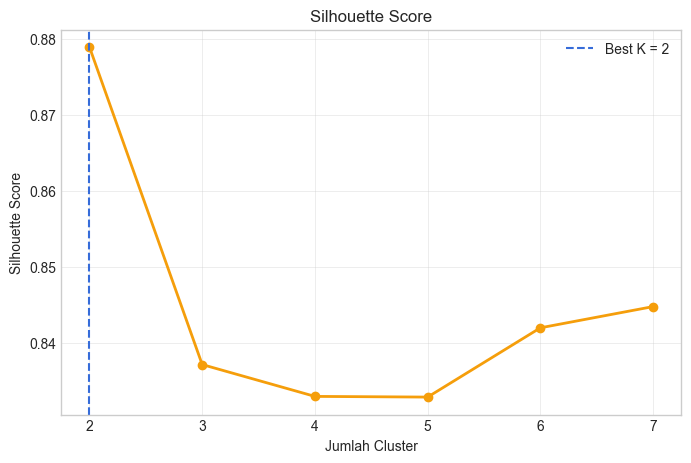

In [37]:
# Agregasikan statistik toko dari DataFrame 'df' yang sudah dibersihkan
store_stats = df.groupby(['Kode Store', 'Nama Store', 'Channel']).agg(
    TotalValue=('Value', 'sum'), # Total nilai penjualan untuk setiap toko
    TotalQty=('Qty', 'sum'), # Total kuantitas terjual untuk setiap toko
    TxCount=('Value', 'count'), # Jumlah transaksi untuk setiap toko
    AvgOrder=('Value', 'mean'), # Rata-rata nilai pesanan untuk setiap toko
    UniqueSKU=('SKU', 'nunique'), # Jumlah SKU unik yang dijual oleh setiap toko
).reset_index()

# Pilih fitur untuk clustering
feat_clust = store_stats[['TotalValue', 'TotalQty', 'TxCount', 'AvgOrder', 'UniqueSKU']]

# Skalakan fitur menggunakan StandardScaler untuk memastikan kontribusi yang sama dari setiap fitur
scaler = StandardScaler()
X_sc = scaler.fit_transform(feat_clust)

sil_scores = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sc)
    sil_scores[k] = silhouette_score(X_sc, labels)

best_k = max(sil_scores, key=sil_scores.get)

print("Silhouette Scores:")
print(sil_scores)
print(f"Best K = {best_k}")
print(f"Best Silhouette Score = {sil_scores[best_k]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color=COLORS[2], lw=2)
plt.axvline(best_k, linestyle='--', label=f'Best K = {best_k}')
plt.title('Silhouette Score')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

Dapat dilihat dari grafik di atas bahwa nilai Silhouette Score tertinggi diperoleh pada K=2, yang menunjukkan bahwa pembagian data menjadi 2 cluster memberikan hasil clustering yang paling baik berdasrkan metrik yang saya punya. Oleh karena itu, saya memilih K=2 sebagai jumlah cluster optimal untuk melakukan segmentasi toko menggunakan K-Means.

### Visualisasi Cluster dengan PCA
Setelah menentukan jumlah cluster optimal, saya melakukan clustering dengan K-Means dan kemudian menggunakan PCA untuk mereduksi dimensi data menjadi 2 komponen utama agar saya bisa memvisualisasikan hasil clustering dengan lebih mudah. Saya membuat scatter plot dari dua komponen PCA, dengan warna yang menunjukkan cluster yang berbeda, sehingga kita bisa melihat bagaimana toko-toko dikelompokkan berdasarkan karakteristik penjualan mereka.

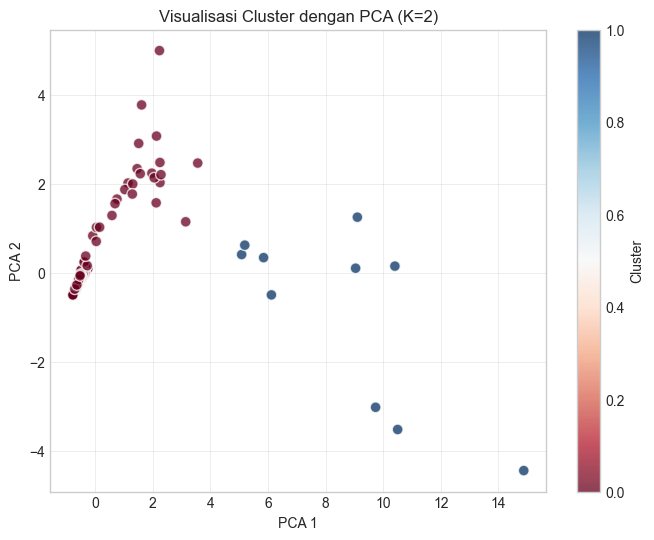

In [38]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
store_stats['Cluster'] = kmeans.fit_predict(X_sc)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

store_stats['PCA1'] = X_pca[:, 0]
store_stats['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    store_stats['PCA1'],
    store_stats['PCA2'],
    c=store_stats['Cluster'],
    cmap='RdBu',
    s=60,
    alpha=0.75,
    edgecolors='white'
)

plt.title(f'Visualisasi Cluster dengan PCA (K={best_k})')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

Dari plot di atas, terlihat bahwa toko-toko terbagi menjadi dua cluster yang cukup terpisah berdasarkan karakteristik penjualan mereka.

### Mencari Profil Cluster
Setelah membagi toko-toko ke dalam cluster, langkah selanjutnya adalah mencari tahu karakteristik apa yang membedakan setiap cluster. Disini saya menghitung rata-rata dari setiap fitur cluster dan membandingkannya untuk melihat perbedaan antara cluster.

PCA Loadings (Feature Contributions):
            PC1   PC2
TotalValue 0.96 -0.25
TotalQty   0.96 -0.26
TxCount    0.93 -0.30
AvgOrder   0.73  0.62
UniqueSKU  0.83  0.37

PC1 explains 77.85% of variance
PC2 explains 14.67% of variance


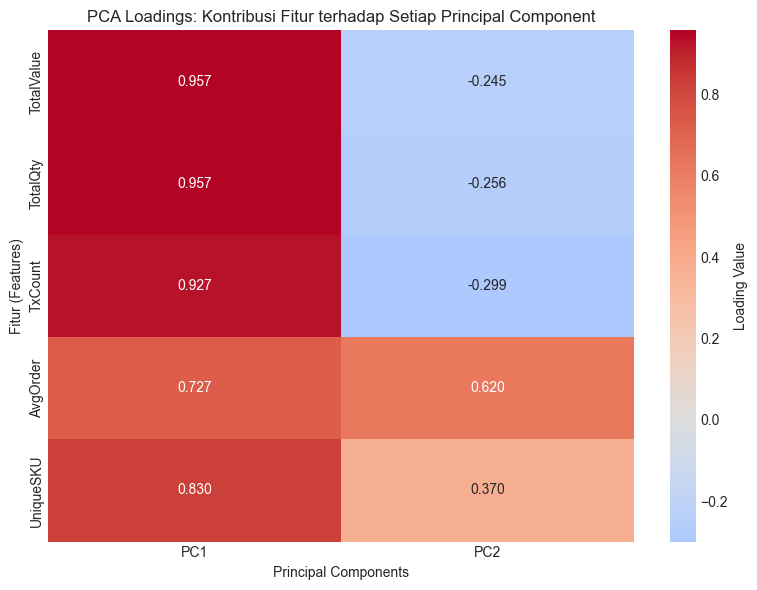


--- Interpretasi PCA Loadings ---
PC1 didominasi oleh: ['TotalValue', 'TotalQty'] (Scale/Activity)
PC2 didominasi oleh: ['AvgOrder', 'UniqueSKU'] (Product Diversity/Value)


In [40]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
feature_names = ['TotalValue', 'TotalQty', 'TxCount', 'AvgOrder', 'UniqueSKU']

loading_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=feature_names
)

print("PCA Loadings (Feature Contributions):")
print(loading_df)

# Also show explained variance
print(f"\nPC1 explains {pca.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.2%} of variance")

# Visualisasi loading sebagai heatmap untuk pemahaman yang lebih baik
plt.figure(figsize=(8, 6))
sns.heatmap(loading_df, annot=True, fmt='.3f', cmap='coolwarm', center=0, cbar_kws={'label': 'Loading Value'})
plt.title('PCA Loadings: Kontribusi Fitur terhadap Setiap Principal Component')
plt.ylabel('Fitur (Features)')
plt.xlabel('Principal Components')
plt.tight_layout()
plt.show()

# Interpretasi:
print("\n--- Interpretasi PCA Loadings ---")
print(f"PC1 didominasi oleh: {loading_df['PC1'].abs().nlargest(2).index.tolist()} (Scale/Activity)")
print(f"PC2 didominasi oleh: {loading_df['PC2'].abs().nlargest(2).index.tolist()} (Product Diversity/Value)")


#### Kesimpulan Segmentasi Toko
Berdasarkan hasil clustering dan analisis PCA, kita dapat menyimpulkan bahwa toko-toko dalam dataset ini terbagi menjadi dua cluster utama:
- Cluster 0: Toko-toko dalam cluster ini cenderung memiliki skala penjualan yang lebih besar, dengan total nilai penjualan, kuantitas, dan jumlah transaksi yang tinggi. Mereka mungkin merupakan toko-toko besar yang sangat aktif dalam penjualan.
- Cluster 1: Toko-toko dalam cluster ini cenderung memiliki nilai pesanan rata-rata yang lebih tinggi dan menjual berbagai macam produk (SKU) yang lebih banyak. Mereka mungkin merupakan toko-toko yang lebih fokus pada penjualan produk bernilai tinggi atau memiliki variasi produk yang lebih luas, meskipun skala penjualan mereka mungkin tidak sebesar toko-toko di Cluster 0.